In [1]:
# CREDIT CARD FRAUD DETECTION ANALYSIS PROJECT USING PYTHON LIB

In [62]:
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("credit.csv")
print(df)

     Transaction ID  Customer Name Merchant Name Transaction Date  \
0          17797619     Pihu Manne          Uber       2024-11-10   
1          50040671   Hiran Vaidya        Zomato       2024-05-20   
2          88177651     Shalv Vasa        Myntra       2024-05-28   
3          24228305  Taran Shanker     Lifestyle       2024-01-09   
4          87307869   Shanaya Kara     Tata Cliq       2024-07-27   
..              ...            ...           ...              ...   
995        97151229   Nitya Ganesh      Flipkart       2024-05-09   
996        46529985    Shray Dubey     Lifestyle       2024-10-02   
997        10160858    Kaira Kumar     Tata Cliq       2024-11-21   
998        48484987      Rati Date     Lifestyle       2024-08-30   
999        20156336    Baiju Dubey          Uber       2024-05-07   

     Transaction Amount (INR) Fraud Risk        Fraud Type          State  \
0                       11673     Medium  Card Not Present      Telangana   
1                

In [ ]:
# TOP 5 ROWS using head() functions

In [7]:
df.head()

,Transaction ID,Customer Name,Merchant Name,Transaction Date,Transaction Amount (INR),Fraud Risk,Fraud Type,State,Card Type,Bank,IsFraud,Fraud Score,Transaction Category,Merchant Location
0,17797619,Pihu Manne,Uber,2024-11-10,11673,Medium,Card Not Present,Telangana,Rupay,ICICI Bank,0,57,Transportation,Bangalore
1,50040671,Hiran Vaidya,Zomato,2024-05-20,16594,Medium,Phishing,Maharashtra,Amex,SBI,0,10,Groceries,Bangalore
2,88177651,Shalv Vasa,Myntra,2024-05-28,23347,Medium,Card Skimming,Uttar Pradesh,Visa,HDFC Bank,0,55,Transportation,Ahmedabad
3,24228305,Taran Shanker,Lifestyle,2024-01-09,20753,Low,Card Skimming,Kerala,Visa,Federal Bank,0,30,E-commerce,Lucknow
4,87307869,Shanaya Kara,Tata Cliq,2024-07-27,6432,Low,Card Skimming,Delhi,Amex,SBI,0,86,Electronics,Hyderabad


In [ ]:
# Total rows & columns 

In [9]:
df.shape

(1000, 14)

In [ ]:
# columns name 

In [10]:
df.columns

Index(['Transaction ID', 'Customer Name', 'Merchant Name', 'Transaction Date',
       'Transaction Amount (INR)', 'Fraud Risk', 'Fraud Type', 'State',
       'Card Type', 'Bank', 'IsFraud', 'Fraud Score', 'Transaction Category',
       'Merchant Location'],
      dtype='object')

In [11]:
#  Information

In [12]:
df.info

<bound method DataFrame.info of      Transaction ID  Customer Name Merchant Name Transaction Date  \
0          17797619     Pihu Manne          Uber       2024-11-10   
1          50040671   Hiran Vaidya        Zomato       2024-05-20   
2          88177651     Shalv Vasa        Myntra       2024-05-28   
3          24228305  Taran Shanker     Lifestyle       2024-01-09   
4          87307869   Shanaya Kara     Tata Cliq       2024-07-27   
..              ...            ...           ...              ...   
995        97151229   Nitya Ganesh      Flipkart       2024-05-09   
996        46529985    Shray Dubey     Lifestyle       2024-10-02   
997        10160858    Kaira Kumar     Tata Cliq       2024-11-21   
998        48484987      Rati Date     Lifestyle       2024-08-30   
999        20156336    Baiju Dubey          Uber       2024-05-07   

     Transaction Amount (INR) Fraud Risk        Fraud Type          State  \
0                       11673     Medium  Card Not Present    

In [13]:
# Check null values

In [14]:
df.isnull().sum()

Transaction ID              0
Customer Name               0
Merchant Name               0
Transaction Date            0
Transaction Amount (INR)    0
Fraud Risk                  0
Fraud Type                  0
State                       0
Card Type                   0
Bank                        0
IsFraud                     0
Fraud Score                 0
Transaction Category        0
Merchant Location           0
dtype: int64

In [15]:
# Duplicated records check

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# check datatype 

In [18]:
df.dtypes

Transaction ID               int64
Customer Name               object
Merchant Name               object
Transaction Date            object
Transaction Amount (INR)     int64
Fraud Risk                  object
Fraud Type                  object
State                       object
Card Type                   object
Bank                        object
IsFraud                      int64
Fraud Score                  int64
Transaction Category        object
Merchant Location           object
dtype: object

In [19]:
# Transaction Date Change into Datetime

In [20]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

In [22]:
df.dtypes

Transaction ID                       int64
Customer Name                       object
Merchant Name                       object
Transaction Date            datetime64[ns]
Transaction Amount (INR)             int64
Fraud Risk                          object
Fraud Type                          object
State                               object
Card Type                           object
Bank                                object
IsFraud                              int64
Fraud Score                          int64
Transaction Category                object
Merchant Location                   object
dtype: object

In [23]:
df["Transaction Date"].head()

0   2024-11-10
1   2024-05-20
2   2024-05-28
3   2024-01-09
4   2024-07-27
Name: Transaction Date, dtype: datetime64[ns]

In [25]:
# stastical summary
df.describe()

,Transaction ID,Transaction Date,Transaction Amount (INR),IsFraud,Fraud Score
count,1.000000e+03,1000,1000.000000,1000.000000,1000.000000
mean,5.486023e+07,2024-06-15 00:46:04.800000,12226.843000,0.286000,53.179000
min,1.003645e+07,2023-12-16 00:00:00,141.000000,0.000000,10.000000
25%,3.235345e+07,2024-03-12 18:00:00,6218.000000,0.000000,29.000000
50%,5.379576e+07,2024-06-12 00:00:00,11999.500000,0.000000,54.000000
75%,7.790521e+07,2024-09-19 00:00:00,18207.750000,1.000000,76.000000
max,9.994398e+07,2024-12-15 00:00:00,24993.000000,1.000000,95.000000
std,2.616482e+07,NaN,7106.084734,0.452115,25.723815


In [27]:
#  counts fraud risk category
df["Fraud Risk"].value_counts()

Fraud Risk
Low         400
Medium      297
High        196
Critical    107
Name: count, dtype: int64

In [31]:
# is fraud category count

df["IsFraud"].value_counts()

IsFraud
0    714
1    286
Name: count, dtype: int64

In [30]:
# fraud type
df["Fraud Type"].value_counts() 

Fraud Type
Card Not Present    231
Card Skimming       209
Identity Theft      195
Account Takeover    188
Phishing            177
Name: count, dtype: int64

In [34]:
# Fraud Transactions Count---------

fraud_count = df["IsFraud"].sum()
print("Total Fraud Translations :-" , fraud_count)

Total Fraud Translations :- 286


In [37]:
# Total Transactions------

Total_transactions = len(df)
print("Total Transactions:-", Total_transactions)

Total Transactions:- 1000


In [41]:
# Fraud Rate-----------

fraud_rate = df["IsFraud"].mean() * 100
print("fraud_rate :-" ,round(fraud_rate,2),"%")


fraud_rate :- 28.6 %


In [42]:
# Fraud Risk distribution

In [43]:
df["Fraud Risk"].value_counts()

Fraud Risk
Low         400
Medium      297
High        196
Critical    107
Name: count, dtype: int64

In [45]:
# Fraud Risk vs Actual Fraud

pd.crosstab(df["Fraud Risk"], df["IsFraud"])

IsFraud,0,1
Fraud Risk,,
Critical,79,28
High,134,62
Low,287,113
Medium,214,83


In [46]:
# Fraud rate by risk level
df.groupby("Fraud Risk")["IsFraud"].mean() * 100

Fraud Risk
Critical    26.168224
High        31.632653
Low         28.250000
Medium      27.946128
Name: IsFraud, dtype: float64

In [47]:
# Fraud Type distribution

df["Fraud Type"].value_counts()

Fraud Type
Card Not Present    231
Card Skimming       209
Identity Theft      195
Account Takeover    188
Phishing            177
Name: count, dtype: int64

In [52]:
# Actual fraud count

fraud_df = df[df["IsFraud"] == 1]
fraud_df["Fraud Type"].value_counts()

Fraud Type
Card Not Present    72
Identity Theft      64
Card Skimming       54
Phishing            50
Account Takeover    46
Name: count, dtype: int64

In [54]:
# Fraud Type percentage


fraud_df["Fraud Type"].value_counts(normalize=True) * 100

Fraud Type
Card Not Present    25.174825
Identity Theft      22.377622
Card Skimming       18.881119
Phishing            17.482517
Account Takeover    16.083916
Name: proportion, dtype: float64

In [60]:
# -----Fraud Type according transaction amount------#


fraud_df.groupby("Fraud Type")["Transaction Amount (INR)"].sum().sort_values(ascending=False)

Fraud Type
Card Not Present    879713
Identity Theft      804353
Card Skimming       627465
Account Takeover    509624
Phishing            485658
Name: Transaction Amount (INR), dtype: int64

In [61]:
# Fraud Type  average transaction amount----------


fraud_df.groupby("Fraud Type")["Transaction Amount (INR)"].mean().sort_values(ascending=False)

Fraud Type
Identity Theft      12568.015625
Card Not Present    12218.236111
Card Skimming       11619.722222
Account Takeover    11078.782609
Phishing             9713.160000
Name: Transaction Amount (INR), dtype: float64

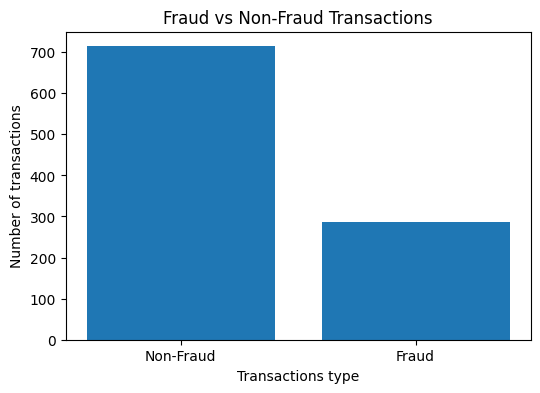

In [67]:
# -------- CHART ANALYSIS --------
# Fraud vs Non-Fraud Transactions


fraud_counts = df["IsFraud"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Non-Fraud" ,"Fraud"],fraud_counts.values)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transactions type")
plt.ylabel("Number of transactions")
plt.show()


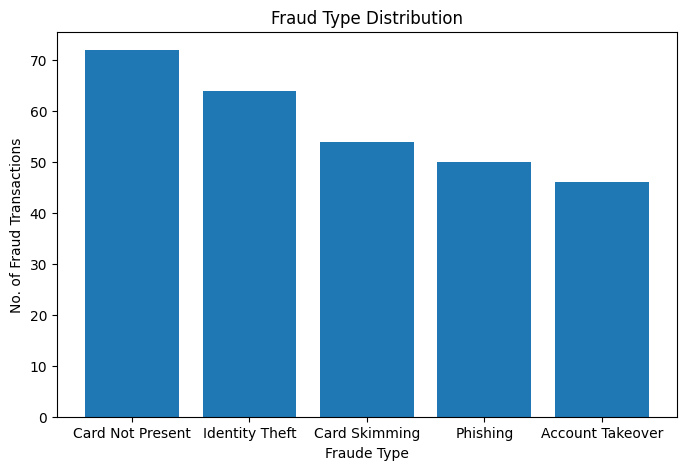

In [71]:
# Fraud Type Distribution



fraud_type = fraud_df["Fraud Type"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(fraud_type.index , fraud_type.values)
plt.title("Fraud Type Distribution")
plt.xlabel("Fraude Type")
plt.ylabel("No. of Fraud Transactions")
plt.show()

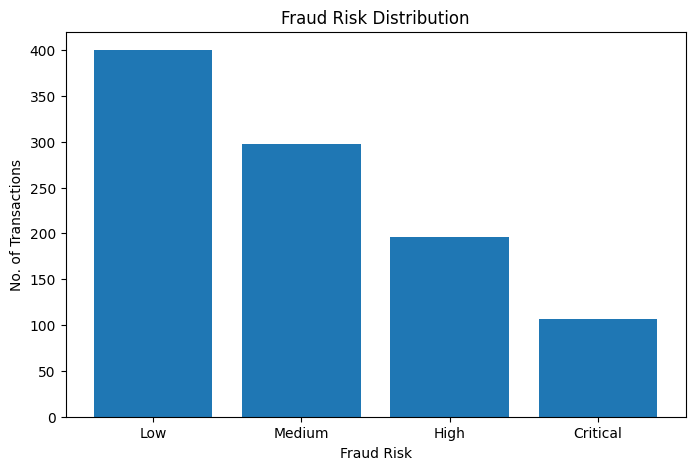

In [72]:
# Fraud Risk Distribution


fraud_risk = df["Fraud Risk"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(fraud_risk.index , fraud_risk.values)
plt.title("Fraud Risk Distribution")
plt.xlabel("Fraud Risk")
plt.ylabel("No. of Transactions")
plt.show()

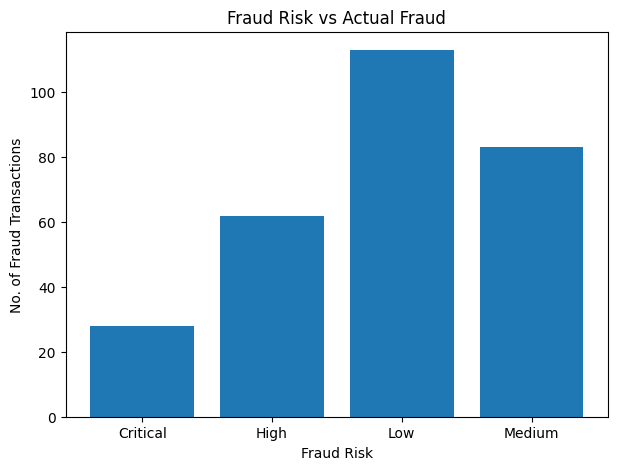

In [76]:
# Fraud Risk vs Actual Fraud ----


risk_fraud = pd.crosstab(df["Fraud Risk"] , df["IsFraud"])[1]

plt.figure(figsize=(7,5))
plt.bar(risk_fraud.index , risk_fraud.values)
plt.title("Fraud Risk vs Actual Fraud")
plt.xlabel("Fraud Risk")
plt.ylabel("No. of Fraud Transactions")
plt.show()


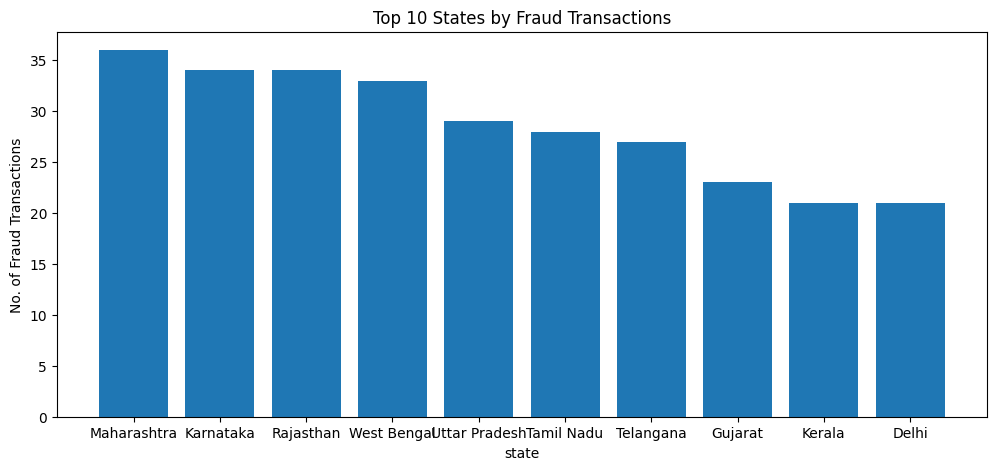

In [80]:
# Top 10 States by Fraud Transactions

state_fraud = fraud_df["State"].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(state_fraud.index , state_fraud.values)
plt.title("Top 10 States by Fraud Transactions")
plt.xlabel("state")
plt.ylabel("No. of Fraud Transactions")
plt.show()



NameError: name 'Plt' is not defined

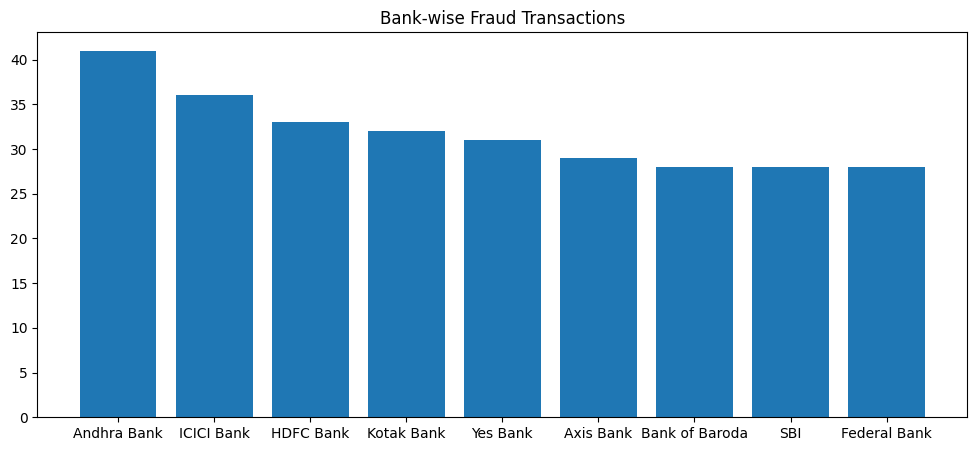

In [83]:
# Bank-wise Fraud Transactions

bank_fraud = fraud_df["Bank"].value_counts()

plt.figure(figsize=(12,5))
plt.bar(bank_fraud.index , bank_fraud.values)
plt.title("Bank-wise Fraud Transactions")
Plt.xlabel("Bank")
plt.ylabel("No. of Fraud Transactions")
plt.show()


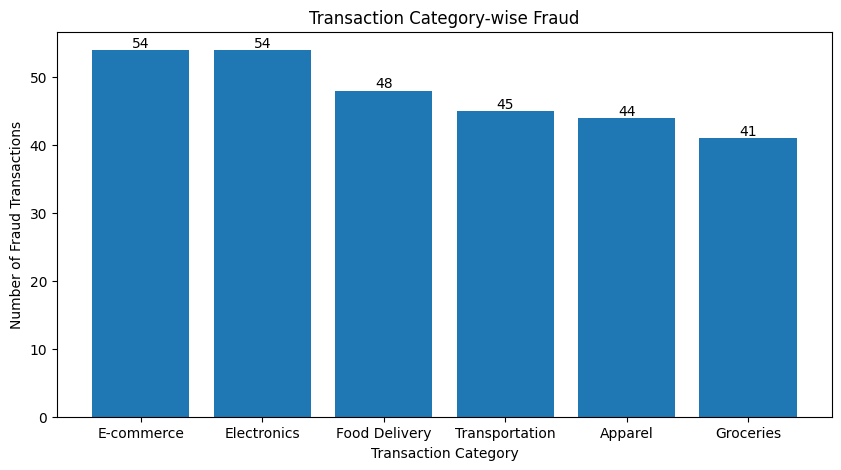

In [95]:
# Transaction Category-wise Fraud


category_fraud = fraud_df["Transaction Category"].value_counts()

plt.figure(figsize=(10,5))
bars = plt.bar(category_fraud.index, category_fraud.values)

plt.title("Transaction Category-wise Fraud")
plt.xlabel("Transaction Category")
plt.ylabel("Number of Fraud Transactions")

plt.bar_label(bars)

plt.show()



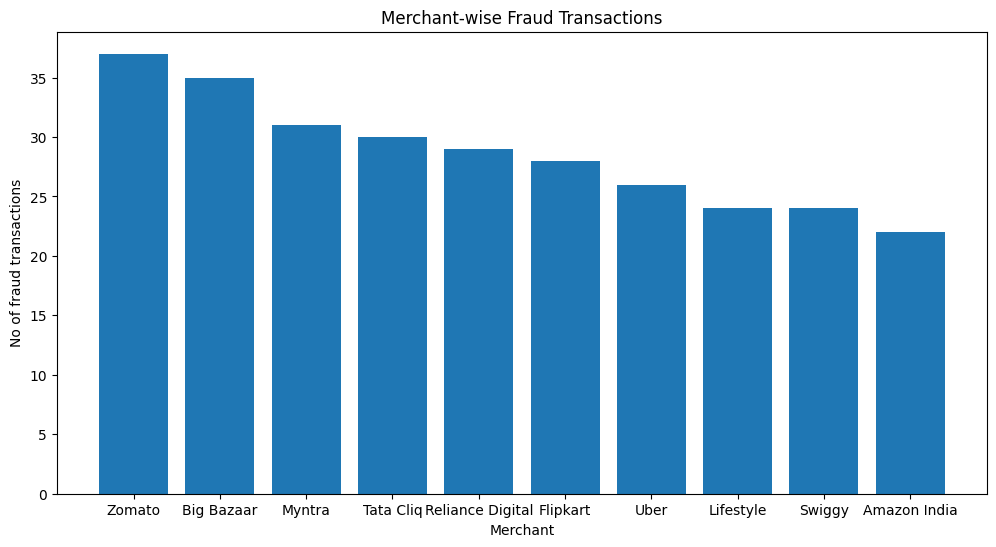

In [100]:
# ----------- Merchant-wise Fraud Transactions

merchant_fraud = fraud_df["Merchant Name"].value_counts()

plt.figure(figsize=(12,6))
plt.bar(merchant_fraud.index , merchant_fraud.values)
plt.title("Merchant-wise Fraud Transactions")
plt.xlabel("Merchant")
plt.ylabel("No of fraud transactions")
plt.show()

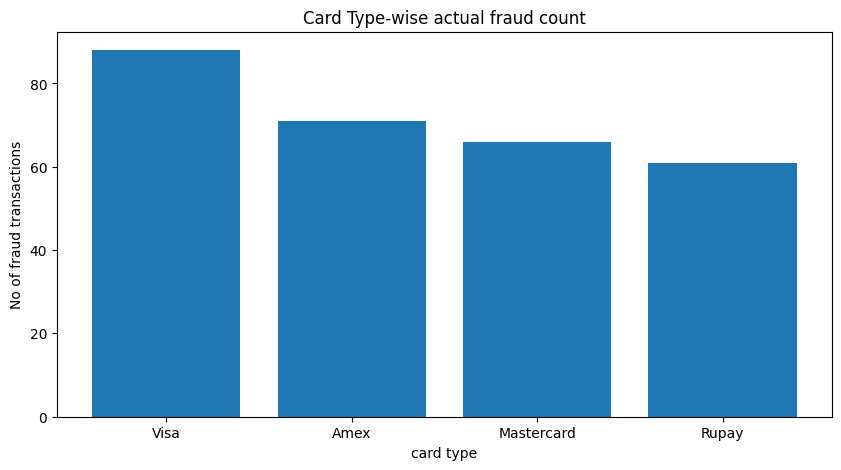

In [101]:
# Card Type-wise actual fraud count


card_fraud = fraud_df["Card Type"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(card_fraud.index , card_fraud.values)
plt.title("Card Type-wise actual fraud count")
plt.xlabel("card type")
plt.ylabel("No of fraud transactions")
plt.show()

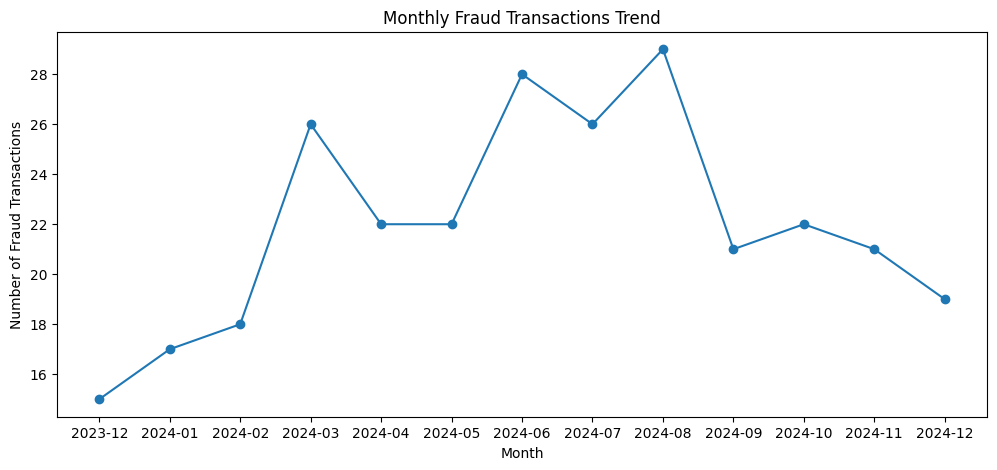

In [103]:
# -------Monthly Fraud Trend-------



monthly_fraud = fraud_df.groupby(
    fraud_df["Transaction Date"].dt.to_period("M")
).size()

plt.figure(figsize=(12,5))
plt.plot(monthly_fraud.index.astype(str), monthly_fraud.values, marker="o")

plt.title("Monthly Fraud Transactions Trend")
plt.xlabel("Month")
plt.ylabel("Number of Fraud Transactions")



plt.show()

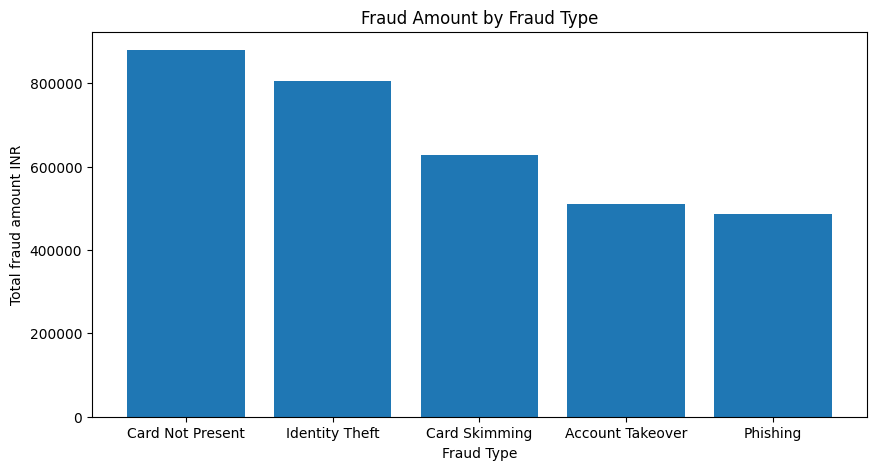

In [106]:
# Fraud Amount by Fraud Type


fraud_amount = fraud_df.groupby("Fraud Type")["Transaction Amount (INR)"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(fraud_amount.index , fraud_amount.values)

plt.title("Fraud Amount by Fraud Type")
plt.xlabel("Fraud Type")
plt.ylabel("Total fraud amount INR")
plt.show()

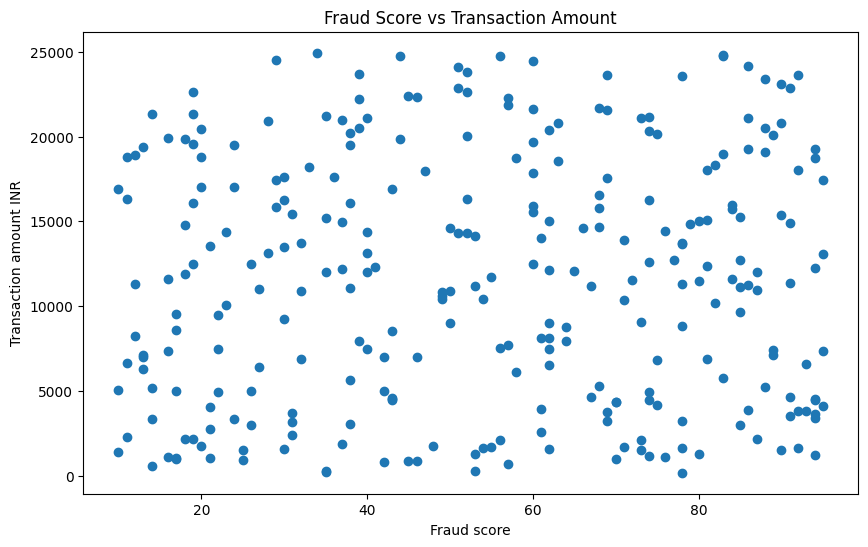

In [107]:
# Fraud Score vs Transaction Amount


plt.figure(figsize=(10,6))
plt.scatter(fraud_df["Fraud Score"],
            fraud_df["Transaction Amount (INR)"])
plt.title("Fraud Score vs Transaction Amount")
plt.xlabel("Fraud score")
plt.ylabel("Transaction amount INR")
plt.show()